In [1]:
import numpy as np
from itertools import product

# generate basis states
#basis = list(product([0,1], repeat=4))  # 4 orbitals
basis = [s for s in product([0,1], repeat=4) if sum(s) == 2]  #restrict the basis to half-filling
dim = len(basis)

def number_op(state, i):
    return state[i]

In [2]:
for i, s in enumerate(basis):
    print(i, s)

0 (0, 0, 1, 1)
1 (0, 1, 0, 1)
2 (0, 1, 1, 0)
3 (1, 0, 0, 1)
4 (1, 0, 1, 0)
5 (1, 1, 0, 0)


In [7]:
print(basis)

[(0, 0, 1, 1), (0, 1, 0, 1), (0, 1, 1, 0), (1, 0, 0, 1), (1, 0, 1, 0), (1, 1, 0, 0)]


In [9]:
def apply_hop(s, i, j):
    # hop electron from j → i
    if s[j] == 1 and s[i] == 0:
        new_state = list(s)
        new_state[i] = 1
        new_state[j] = 0
        return tuple(new_state)
    return None

In [10]:
def hubbard_hamiltonian(U, t=1.0):

    H = np.zeros((dim, dim))

    for i, s in enumerate(basis):

        # interaction
        n1 = s[0]*s[1]
        n2 = s[2]*s[3]
        H[i,i] += U * (n1 + n2)

        # hopping: site1 <-> site2
        for spin in [0,1]:  # 0=up, 1=down

            a = spin       # site 1
            b = spin + 2   # site 2

            sp = apply_hop(s, a, b)
            if sp:
                j = basis.index(sp)
                H[i,j] += -t

            sp = apply_hop(s, b, a)
            if sp:
                j = basis.index(sp)
                H[i,j] += -t

    return H

In [11]:
def ground_state_energy(U):

    H = hubbard_hamiltonian(U)

    eigvals = np.linalg.eigh(H)[0]

    return np.min(eigvals)

In [12]:
print(ground_state_energy(4.0))

-0.8284271247461888


In [13]:
def fermionic_sign(state, i, j):

    # count occupied orbitals between i and j
    if i < j:
        count = sum(state[i+1:j])
    else:
        count = sum(state[j+1:i])

    return (-1) ** count

In [14]:
def apply_hop(state, i, j):
    """
    hop fermion from j -> i
    """

    # must have particle at j
    # must have empty site at i
    if state[j] == 1 and state[i] == 0:

        new_state = list(state)

        new_state[i] = 1
        new_state[j] = 0

        sign = fermionic_sign(state, i, j)

        return tuple(new_state), sign

    return None, 0

In [15]:
def hubbard_hamiltonian(U, t=1.0):

    H = np.zeros((dim, dim))

    for i, s in enumerate(basis):

        # interaction
        n1 = s[0]*s[1]
        n2 = s[2]*s[3]
        H[i,i] += U * (n1 + n2)

        # hopping: site1 <-> site2
        for spin in [0,1]:

           a = spin
           b = spin + 2

           # hop b -> a
           sp, sign = apply_hop(s, a, b)

           if sp:
             j = basis.index(sp)
             H[i,j] += -t * sign

           # hop a -> b
           sp, sign = apply_hop(s, b, a)

           if sp:
              j = basis.index(sp)
              H[i,j] += -t * sign

    return H

In [16]:
def ground_state_energy(U):

    H = hubbard_hamiltonian(U)

    eigvals = np.linalg.eigh(H)[0]

    return np.min(eigvals)

In [17]:
print(ground_state_energy(4.0))

-0.8284271247461892


In [18]:
U_values = np.linspace(0, 8, 500)

data = []

for U in U_values:
    E = ground_state_energy(U)
    data.append([U, E])

data = np.array(data)

In [19]:
from sklearn.neural_network import MLPRegressor

X = data[:, 0].reshape(-1, 1)
y = data[:, 1]

model = MLPRegressor(hidden_layer_sizes=(64,64))
model.fit(X, y)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


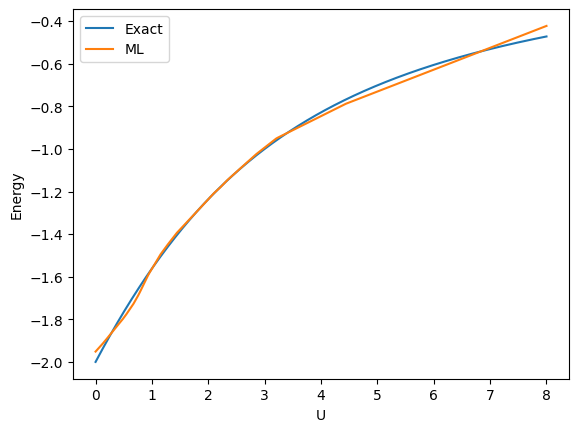

In [20]:
import matplotlib.pyplot as plt

y_pred = model.predict(X)

plt.plot(X, y, label="Exact")
plt.plot(X, y_pred, label="ML")

plt.legend()
plt.xlabel("U")
plt.ylabel("Energy")

plt.show()

In [21]:
from qiskit_nature.second_q.hamiltonians import FermiHubbardModel
from qiskit_nature.second_q.hamiltonians.lattices import LineLattice

t = 1.0
U = 4.0
# define lattice WITH hopping
lattice = LineLattice(num_nodes=2, edge_parameter=t)

# now build model (no hopping argument here)
model = FermiHubbardModel(
    lattice=lattice,
    onsite_interaction=U
)

second_q_op = model.second_q_op()

In [22]:
from qiskit_nature.second_q.mappers import JordanWignerMapper

mapper = JordanWignerMapper()

qubit_hamiltonian = mapper.map(second_q_op)

In [23]:
print(qubit_hamiltonian)

SparsePauliOp(['IIII', 'IYZY', 'IXZX', 'YZYI', 'XZXI', 'IIZI', 'IIIZ', 'IIZZ', 'ZIII', 'IZII', 'ZZII'],
              coeffs=[ 2. +0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j, -1. +0.j, -1. +0.j,
  1. +0.j, -1. +0.j, -1. +0.j,  1. +0.j])


In [24]:
from qiskit.quantum_info import Operator

H_mat = Operator(qubit_hamiltonian).data
eigvals = np.linalg.eigvalsh(H_mat)

print(min(eigvals))
print(eigvals)

-1.0
[-1.         -1.         -0.82842712  0.          0.          0.
  0.          1.          1.          3.          3.          4.
  4.82842712  5.          5.          8.        ]


In [25]:
from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import TwoLocal
from qiskit.primitives import StatevectorEstimator

estimator = StatevectorEstimator()

#TwoLocal ansatz for full Hilbert space
ansatz = TwoLocal(
    rotation_blocks='ry',
    entanglement_blocks='cz',
    reps=2
)

optimizer = COBYLA(maxiter=1000)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer
)

result = vqe.compute_minimum_eigenvalue(qubit_hamiltonian)

print("VQE energy:", result.eigenvalue.real)

/tmp/ipykernel_106180/3211955228.py:9: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(


VQE energy: -0.9999865520651383


In [26]:
print(U)

4.0


In [27]:
from qiskit_nature.second_q.circuit.library import UCCSD

num_particles = (1, 1)  # 1 up, 1 down → total 2 electrons
num_spatial_orbitals = 2

ansatz = UCCSD(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper
)

In [28]:
optimizer = COBYLA(maxiter=1000)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer
)

result = vqe.compute_minimum_eigenvalue(qubit_hamiltonian)

print("VQE energy:", result.eigenvalue.real)

/home/abdu924/qiskit/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/abdu924/qiskit/lib/python3.13/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


VQE energy: 0.0


In [29]:
from qiskit import QuantumCircuit

initial_state = QuantumCircuit(4)

initial_state.x(0)
initial_state.x(1)

In [30]:
from qiskit.circuit.library import ExcitationPreserving

ansatz = ExcitationPreserving(
    num_qubits=4,
    reps=2,
    initial_state=initial_state
)

/tmp/ipykernel_106180/4260011955.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.excitation_preserving.ExcitationPreserving`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.excitation_preserving instead.
  ansatz = ExcitationPreserving(


In [31]:
from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorEstimator

estimator = StatevectorEstimator()

optimizer = COBYLA(maxiter=1000)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer
)

result = vqe.compute_minimum_eigenvalue(qubit_hamiltonian)

print(result.eigenvalue.real)

-0.8258468924064647


In [32]:
E_exact = ground_state_energy(U)

print("Exact:", E_exact)
print("VQE:", result.eigenvalue.real)

Exact: -0.8284271247461892
VQE: -0.8258468924064647


In [33]:
U_values = np.linspace(0, 8, 20)

dataset = []

for U in U_values:

    # build Hamiltonian
    model = FermiHubbardModel(
    lattice=lattice,
    onsite_interaction=U
     )

    second_q_op = model.second_q_op()
    qubit_hamiltonian = mapper.map(second_q_op)

    result = vqe.compute_minimum_eigenvalue(qubit_hamiltonian)

    dataset.append({
        "U": U,
        "energy": result.eigenvalue.real,
        "theta": result.optimal_point
    })

In [34]:
print(dataset[:4])

[{'U': np.float64(0.0), 'energy': np.float64(-1.999973580127421), 'theta': array([ 0.58595646,  2.68180299,  1.39309652,  2.6955712 , -0.47155929,
       -0.11361011,  0.72218012,  2.34198742,  2.71183432,  0.88981926,
        1.69531684, -1.41526484,  1.83764736,  2.92916007,  0.53262334,
        1.25796256,  0.69159569, -0.75206728,  1.91784951,  2.96046718,
        1.3370061 , -0.71273529,  2.16319833,  2.95290094])}, {'U': np.float64(0.42105263157894735), 'energy': np.float64(-1.8002552692446956), 'theta': array([ 2.15741144, -0.29302743,  3.04749434,  1.00416214,  1.50096567,
       -0.83639246, -1.10312243, -0.30746054, -0.18626624, -3.33217738,
       -0.391847  ,  4.10107887,  0.30267658, -1.21999147,  0.85477249,
       -1.97348286,  2.22255755, -0.80984927,  1.16810947, -3.27716682,
       -1.48045191,  3.02348826, -1.1033811 , -0.42476326])}, {'U': np.float64(0.8421052631578947), 'energy': np.float64(-1.6227877033276006), 'theta': array([ 2.72730061,  1.91744014, -1.31296923

In [35]:
def energy_spectrum(U):

    H = hubbard_hamiltonian(U)

    eigvals = np.linalg.eigh(H)[0]

    return eigvals

In [36]:
U_vals = np.linspace(0, 8, 10)
for U in U_vals:
  print(energy_spectrum(U))

[-2.00000000e+00  0.00000000e+00  0.00000000e+00  3.94513211e-17
  4.82700445e-16  2.00000000e+00]
[-1.60434321e+00 -5.54667824e-32  0.00000000e+00  0.00000000e+00
  8.88888889e-01  2.49323210e+00]
[-1.29974618e+00 -2.77333912e-32  0.00000000e+00  0.00000000e+00
  1.77777778e+00  3.07752396e+00]
[-1.07036752e+00 -9.24446373e-33  0.00000000e+00  4.44089210e-16
  2.66666667e+00  3.73703418e+00]
[-8.98132129e-01 -6.93334780e-33  0.00000000e+00  0.00000000e+00
  3.55555556e+00  4.45368768e+00]
[-7.67472010e-01 -5.54667824e-33  0.00000000e+00  0.00000000e+00
  4.44444444e+00  5.21191645e+00]
[-6.66666667e-01 -2.31111593e-32  0.00000000e+00  0.00000000e+00
  5.33333333e+00  6.00000000e+00]
[-5.87403773e-01 -3.96191303e-33  0.00000000e+00  0.00000000e+00
  6.22222222e+00  6.80962599e+00]
[-5.23902167e-01 -3.46667390e-33  0.00000000e+00  0.00000000e+00
  7.11111111e+00  7.63501328e+00]
[-4.72135955e-01 -3.08148791e-33  0.00000000e+00  0.00000000e+00
  8.00000000e+00  8.47213595e+00]


In [37]:
def compute_gap(U):

    eigvals = energy_spectrum(U)

    return eigvals[1] - eigvals[0]

In [38]:
U_values = np.linspace(0, 8, 100)

data = []

for U in U_values:

    gap = compute_gap(U)

    # define threshold
    label = 1 if gap > 0.5 else 0   # 1 = insulator, 0 = metal

    data.append([U, gap, label])

In [39]:
from sklearn.ensemble import RandomForestClassifier

import numpy as np

data = np.array(data)

X = data[:, 0].reshape(-1, 1)   # U
y = data[:, 2]                  # label

model = RandomForestClassifier()
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

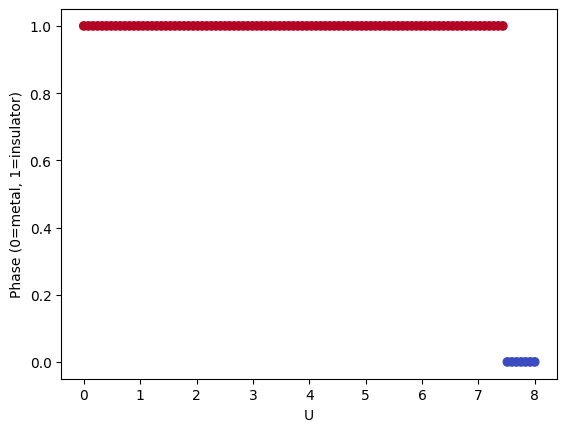

In [40]:
import matplotlib.pyplot as plt

plt.scatter(X, y, c=y, cmap='coolwarm')

plt.xlabel("U")
plt.ylabel("Phase (0=metal, 1=insulator)")

plt.show()

In [41]:
def make_initial_state_N1():
    qc = QuantumCircuit(4)
    qc.x(0)  # one electron (spin up at site 0)
    return qc

def make_initial_state_N2():
    qc = QuantumCircuit(4)
    qc.x(0)  # up electron
    qc.x(2)  # down electron
    return qc

def make_initial_state_N3():
    qc = QuantumCircuit(4)
    qc.x(0)
    qc.x(1)
    qc.x(2)  # 3 electrons total
    return qc

In [42]:
from qiskit.circuit.library import excitation_preserving
#from qiskit.algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.minimum_eigensolvers import VQE
#from qiskit.primitives import Estimator
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import StatevectorEstimator

estimator = StatevectorEstimator()

def run_vqe(H, initial_state):

    ansatz = initial_state.compose(
        excitation_preserving(
            num_qubits=4,
            reps=2
        )
    )

    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=SLSQP()
    )

    result = vqe.compute_minimum_eigenvalue(H)

    return result.eigenvalue.real

In [43]:
def charge_gap(U):
    # build Hamiltonian
    model = FermiHubbardModel(
    lattice=lattice,
    onsite_interaction=U
     )

    second_q_op = model.second_q_op()
    qubit_hamiltonian = mapper.map(second_q_op)

    H = qubit_hamiltonian

    E1 = run_vqe(H, make_initial_state_N1())
    E2 = run_vqe(H, make_initial_state_N2())
    E3 = run_vqe(H, make_initial_state_N3())

    return E3 + E1 - 2 * E2

In [44]:
U_values = np.linspace(0, 8, 100)

data = []

for U in U_values:

    gap = charge_gap(U)

    # define threshold
    label = 1 if gap > 0.5 else 0   # 1 = insulator, 0 = metal

    data.append([U, gap, label])

In [45]:
data = np.array(data)

X = data[:, 0].reshape(-1, 1)   # U
y = data[:, 1]   

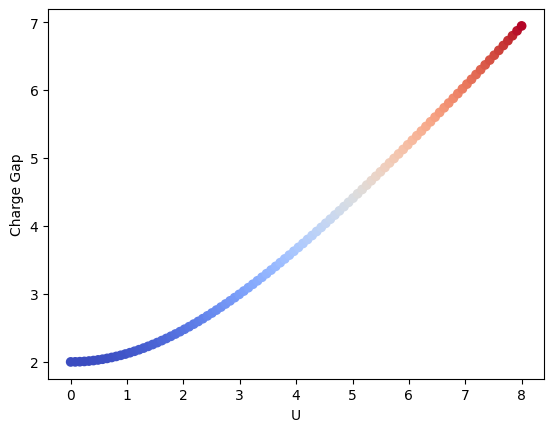

In [46]:
import matplotlib.pyplot as plt

plt.scatter(X, y, c=y, cmap='coolwarm')

plt.xlabel("U")
plt.ylabel("Charge Gap")

plt.show()

In [49]:
from qiskit_nature.second_q.operators import FermionicOp

double_occ_op = FermionicOp(
    {
        "+_0 -_0 +_1 -_1": 1.0
    },
    num_spin_orbitals=4
)

szsz_op = FermionicOp(
    {
        "+_0 -_0 +_2 -_2": 0.25,
        "+_1 -_1 +_3 -_3": 0.25,
        "+_0 -_0 +_3 -_3": -0.25,
        "+_1 -_1 +_2 -_2": -0.25,
    },
    num_spin_orbitals=4
)

In [50]:
double_occ_qubit = mapper.map(double_occ_op)
szsz_qubit = mapper.map(szsz_op)

In [52]:
def operator_scan(U):
    # build Hamiltonian
    model = FermiHubbardModel(
    lattice=lattice,
    onsite_interaction=U
     )

    second_q_op = model.second_q_op()
    qubit_hamiltonian = mapper.map(second_q_op)

    H = qubit_hamiltonian

    initial_state = make_initial_state_N2()
    ansatz = initial_state.compose(
        excitation_preserving(
            num_qubits=4,
            reps=2
        )
    )

    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=SLSQP()
    )

    result = vqe.compute_minimum_eigenvalue(H)
    optimal_circuit = ansatz.assign_parameters(result.optimal_point)
    duble_occ =  estimator.run([(optimal_circuit, double_occ_qubit)]).result()[0].data.evs
    corr = estimator.run([(optimal_circuit, szsz_qubit)]).result()[0].data.evs
    
    return duble_occ, corr

In [53]:
data = []
for U in U_values:

    value = operator_scan(U)

    data.append([U, value[0], value[1]])

In [54]:
data = np.array(data)

X = data[:, 0].reshape(-1, 1)   # U
y = data[:, 1]   
z = data[:, 2]

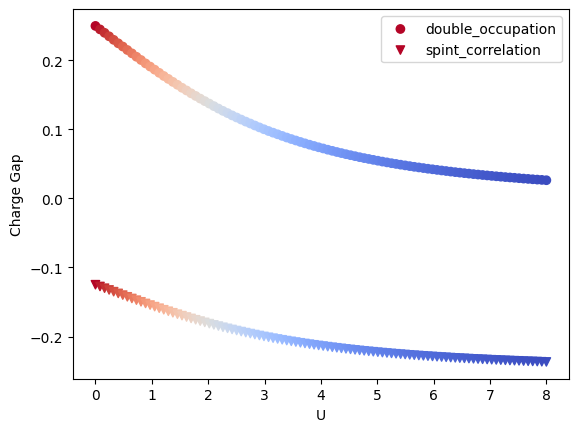

In [68]:
import matplotlib.pyplot as plt

plt.scatter(X, y, c=y, cmap='coolwarm', marker='o', label='double_occupation')
plt.scatter(X, z, c=y, cmap='coolwarm', marker='v',  label='spint_correlation' )
plt.xlabel("U")
plt.ylabel("Charge Gap")
plt.legend()
plt.show()
